In [1]:

import os
import re
import json
import math
import sqlite3
import random
from datetime import datetime, timedelta
from typing import Any, Dict, List
import ollama
from langchain_ollama import ChatOllama

import pandas as pd
import matplotlib.pyplot as plt


PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:


DB_PATH = "coffee_sales.db"
CHART_PATH = "coffee_analysis.png"




In [3]:
# ============================================================
# STEP 1 — CREATE AND SEED DATABASE
# ============================================================

def create_database(db_path: str = DB_PATH) -> None:
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()

    cur.execute("""
    CREATE TABLE IF NOT EXISTS products (
        product   TEXT PRIMARY KEY,
        category  TEXT NOT NULL,
        cost      REAL NOT NULL,
        price     REAL NOT NULL
    )
    """)

    cur.execute("""
    CREATE TABLE IF NOT EXISTS sales (
        id       INTEGER PRIMARY KEY AUTOINCREMENT,
        date     TEXT NOT NULL,
        product  TEXT NOT NULL,
        qty      INTEGER NOT NULL,
        price    REAL NOT NULL,
        revenue  REAL NOT NULL,
        FOREIGN KEY (product) REFERENCES products(product)
    )
    """)

    conn.commit()
    conn.close()


def seed_database(db_path: str = DB_PATH) -> None:
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()

    # Avoid reseeding if data already exists
    cur.execute("SELECT COUNT(*) FROM products")
    product_count = cur.fetchone()[0]

    cur.execute("SELECT COUNT(*) FROM sales")
    sales_count = cur.fetchone()[0]

    if product_count > 0 and sales_count > 0:
        conn.close()
        return

    products = [
        ("Espresso", "Hot", 0.80, 3.50),
        ("Latte", "Hot", 1.20, 4.80),
        ("Cappuccino", "Hot", 1.10, 4.50),
        ("Cold Brew", "Cold", 1.00, 4.20),
        ("Matcha", "Cold", 1.30, 5.00),
        ("Hot Chocolate", "Hot", 0.90, 4.00),
    ]

    cur.executemany("""
    INSERT OR REPLACE INTO products (product, category, cost, price)
    VALUES (?, ?, ?, ?)
    """, products)

    start_date = datetime(2024, 1, 1)
    end_date = datetime(2024, 12, 31)

    def seasonal_multiplier(product: str, month: int) -> float:
        hot_products = {"Espresso", "Latte", "Cappuccino", "Hot Chocolate"}
        cold_products = {"Cold Brew", "Matcha"}

        if product in hot_products:
            if month in [11, 12, 1, 2]:
                return 1.30
            if month in [6, 7, 8]:
                return 0.85
            return 1.00

        if product in cold_products:
            if month in [6, 7, 8]:
                return 1.35
            if month in [11, 12, 1, 2]:
                return 0.80
            return 1.00

        return 1.00

    current = start_date
    while current <= end_date:
        weekday = current.weekday()  # Monday=0, Sunday=6
        is_weekend = weekday >= 5

        for product, category, cost, price in products:
            base_qty = {
                "Espresso": 20,
                "Latte": 16,
                "Cappuccino": 14,
                "Cold Brew": 12,
                "Matcha": 10,
                "Hot Chocolate": 11,
            }[product]

            weekday_multiplier = 1.15 if not is_weekend else 0.90
            season_mult = seasonal_multiplier(product, current.month)

            noise = random.uniform(0.75, 1.25)
            qty = max(1, int(base_qty * weekday_multiplier * season_mult * noise))

            revenue = round(qty * price, 2)

            cur.execute("""
            INSERT INTO sales (date, product, qty, price, revenue)
            VALUES (?, ?, ?, ?, ?)
            """, (current.strftime("%Y-%m-%d"), product, qty, price, revenue))

        current += timedelta(days=1)

    conn.commit()
    conn.close()

create_database()
seed_database()

print("Database ready:", DB_PATH)

Database ready: coffee_sales.db


In [4]:


def call_llm(system_prompt: str, user_prompt: str) -> str:
    llm = ChatOllama(model='llama3.2', temperature=0)
    response = llm.invoke([
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ])
    return response.content.strip()




In [15]:
# ============================================================
# SYSTEM PROMPTS
# ============================================================

SQL_WRITER_SYSTEM_PROMPT = """
You are an expert SQL analyst for a coffee shop SQLite database.

Database schema:

Table: sales
- id
- date
- product
- qty
- price
- revenue

Table: products
- product
- category
- cost
- price

CRITICAL:

If you use unsupported functions like:
- strftime('%A')
- strftime('%Q')
- EXTRACT()

your answer is INVALID.
 
STRICT RULES (MANDATORY):

- Write ONLY SQLite-compatible SQL
- Return ONLY SQL (no explanation)
- Use only listed tables and columns



Quarter logic (MANDATORY when question mentions quarter):
- Calculate quarter using:
  ((CAST(strftime('%m', date) AS INTEGER) - 1) / 3) + 1

Top N logic:
- If question says "top N per group" (like per quarter),
  you MUST use ROW_NUMBER() OVER (PARTITION BY ... ORDER BY ...)
- Then filter using WHERE rn <= N
- NEVER use global LIMIT for "each group" questions

Aggregation rules:
- Use SUM(qty) for best-selling products unless specified otherwise

Example (IMPORTANT):

Question:
"Top 3 products each quarter"

Correct pattern:
WITH data AS (
    SELECT
        ((CAST(strftime('%m', date) AS INTEGER) - 1) / 3) + 1 AS quarter,
        product,
        SUM(qty) AS total_qty
    FROM sales
    GROUP BY quarter, product
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY quarter
            ORDER BY total_qty DESC
        ) AS rn
    FROM data
)
SELECT *
FROM ranked
WHERE rn <= 3;

Follow this pattern when similar question appears.
"""

SQL_VALIDATOR_SYSTEM_PROMPT = """
You are a SQL validator for a coffee shop SQLite database.

Your job is to validate a SQL query and check for:
- Correct table names: sales, products
- Correct column names: id, date, product, qty, price, revenue, category, cost
- Valid SQLite syntax
- No MySQL/PostgreSQL-only features
- No harmful queries such as DROP, DELETE, UPDATE, INSERT, ALTER, TRUNCATE
- Missing GROUP BY when aggregation and non-aggregated columns are mixed
- SQLite supports strftime()
- Do NOT use EXTRACT()
- Reject unsupported SQLite date formats like %Q
- Ensure the SQL actually answers the user's question
- If user asks "each quarter", query must partition or group by quarter

Return your answer in EXACTLY this format:

VALID: <yes or no>
ISSUES: <list any problems found, or "None">
FIXED QUERY: <corrected query if there were issues, otherwise same query>

Important rules:
- FIXED QUERY must always contain a real SQL query
- If the original SQL is already valid, copy the same SQL exactly into FIXED QUERY
- Do not write phrases like "Same query", "No issues found", or "Valid and correct"
- Return only the three lines above

Return only the three lines above.
"""

GRAPH_PLOTTER_SYSTEM_PROMPT = """
You are a data visualisation expert.

Your task is to write complete, runnable matplotlib Python code that plots the query results.

Rules:
 The pandas DataFrame is already available in a variable named df
- Do NOT recreate df
- Do NOT hardcode sample rows
- Always inspect and use the existing df columns exactly as provided
- Decide the best chart type based on the data:
  * Time series data -> line chart
  * Category comparison -> bar chart
  * Proportions -> pie chart
  * Two numeric variables -> scatter plot
- Write complete, runnable matplotlib Python code.
- The code will receive a pandas DataFrame variable named df.
- Always include:
  - title
  - axis labels
  - legend if needed
  - tight_layout()
- Always end with:
  plt.savefig('coffee_analysis.png', dpi=150, bbox_inches='tight')
- Use a professional color palette (avoid default blue only).
- Return ONLY Python code, no explanation, no markdown fences.

CRITICAL RULE:
- For bar charts:
  - If a column represents categories (like product, category, day, month), use it on X-axis
  - If a column represents numeric values (like revenue, total_qty), use it on Y-axis

Examples:
- product vs revenue → X=product, Y=revenue
- month vs revenue → X=month, Y=revenue

NEVER swap axes.
"""

GRAPH_REVIEWER_SYSTEM_PROMPT = """
You are a coffee shop business analyst.

You will receive:
- the original user question
- the SQL query that was run
- the raw data results
- confirmation that the chart was saved

Rules:
- Answer only from the SQL results provided
- Do not assume trends unless time-based data is present
- Do not compare with previous periods unless such data is explicitly provided
- Do not invent percentages unless you calculate them from the given results
- If the result is empty or incomplete, say that clearly
- Include one practical recommendation based only on the data

Return only the business report.
"""



In [6]:

# ============================================================
# AGENT 1 — SQL WRITER
# ============================================================

def sql_writer_agent(question: str) -> str:
    sql = call_llm(SQL_WRITER_SYSTEM_PROMPT, question).strip()

    # Remove accidental markdown fences if the model adds them
    sql = re.sub(r"^```sql\s*", "", sql, flags=re.IGNORECASE)
    sql = re.sub(r"^```\s*", "", sql)
    sql = re.sub(r"\s*```$", "", sql)

    return sql.strip()



In [7]:

# ============================================================
# AGENT 2 — SQL VALIDATOR
# ============================================================

def parse_validator_output(text: str) -> Dict[str, Any]:
    valid_match = re.search(r"VALID:\s*(yes|no)", text, re.IGNORECASE)
    issues_match = re.search(r"ISSUES:\s*(.*)", text, re.IGNORECASE)
    fixed_match = re.search(r"FIXED QUERY:\s*([\s\S]*)", text, re.IGNORECASE)

    valid = bool(valid_match and valid_match.group(1).strip().lower() == "yes")
    issues = issues_match.group(1).strip() if issues_match else "Validator output parsing failed."
    fixed_query = fixed_match.group(1).strip() if fixed_match else ""

    return {
        "valid": valid,
        "issues": issues,
        "fixed_query": fixed_query,
        "raw": text
    }


def sql_validator_agent(question: str, sql: str) -> Dict[str, Any]:
    user_prompt = f"""
User question:
{question}

Validate this SQL query:

{sql}
"""
    raw = call_llm(SQL_VALIDATOR_SYSTEM_PROMPT, user_prompt).strip()
    parsed = parse_validator_output(raw)

    original_sql = sql.strip()
    fixed_sql = parsed["fixed_query"].strip()

    # Safety fallback checks in Python too
    lowered = original_sql.lower()
    harmful_patterns = ["drop ", "delete ", "update ", "insert ", "alter ", "truncate "]
    if any(p in lowered for p in harmful_patterns):
        return {
            "valid": False,
            "issues": "Potentially harmful query detected.",
            "fixed_query": "",
            "raw": raw
        }

    # If validator returns text instead of actual SQL, keep original SQL
    bad_fixed_values = [
        "same query",
        "valid and correct",
        "no issues",
        "no issues found",
        "same query (no issues found)",
        "same query (valid and correct)"
    ]

    if fixed_sql == "" or any(fixed_sql.lower().startswith(x) for x in bad_fixed_values):
        parsed["fixed_query"] = original_sql
        if parsed["issues"].lower() == "none":
            parsed["valid"] = True
        return parsed

    q = question.lower()
    orig = original_sql.lower()
    fixed = fixed_sql.lower()
    if "top 3" in q and "quarter" in q:
       if "group by quarter, product" in orig:
           if "group by strftime('%y-%m', date), product" in fixed or "group by strftime('%Y-%m', date), product" in fixed:
               parsed["fixed_query"] = original_sql
               parsed["valid"] = True
               parsed["issues"] = "Validator changed correct quarter grouping into month grouping, so original SQL was kept."
               return parsed

    # Protect row_number partition logic generally
    if "row_number()" in orig and "row_number()" in fixed:
        if "partition by" in orig and "partition by" not in fixed:
            parsed["fixed_query"] = original_sql
            parsed["valid"] = True
            parsed["issues"] = "Validator removed correct partitioning logic, so original SQL was kept."
            return parsed

    # Protect correct quarter formula
    correct_quarter_formula = "strftime('%m'" in orig and "/ 3) + 1" in orig
    if "quarter" in q and correct_quarter_formula:
        fixed_broke_quarter = "strftime('%m'" not in fixed
        if fixed_broke_quarter:
            parsed["fixed_query"] = original_sql
            parsed["valid"] = True
            parsed["issues"] = "Validator changed correct quarter calculation, so original SQL was kept."
            return parsed

    # Reject obviously bad SQLite fixes
    bad_sql_patterns = [
        "strftime('%q'",
        "extract(",
        "same query",
        "valid and correct"
    ]

    if any(p in fixed for p in bad_sql_patterns):
        parsed["fixed_query"] = original_sql
        parsed["valid"] = False
        parsed["issues"] = "Validator returned unsupported or invalid SQLite syntax. Original SQL kept for review."
        return parsed

    # Prevent top-per-group logic from being replaced by global LIMIT
    if "top" in q and "each" in q:
        original_has_partition = "partition by" in orig
        fixed_has_global_limit = "limit" in fixed and "partition by" not in fixed

        if original_has_partition and fixed_has_global_limit:
            parsed["fixed_query"] = original_sql
            parsed["valid"] = True
            parsed["issues"] = "Validator replaced top-per-group logic with global LIMIT, so original SQL was kept."
            return parsed

    parsed["fixed_query"] = fixed_sql
    return parsed



In [8]:

# ============================================================
# STEP 4 — EXECUTE VALIDATED QUERY
# ============================================================

def ensure_limit(sql: str, max_rows: int = 100) -> str:
    sql_clean = sql.strip().rstrip(";")
    if re.search(r"\blimit\b", sql_clean, re.IGNORECASE):
        return sql_clean + ";"
    return f"{sql_clean} LIMIT {max_rows};"


def execute_query(sql: str, db_path: str = DB_PATH) -> Dict[str, Any]:
    safe_sql = ensure_limit(sql, 100)

    try:
        conn = sqlite3.connect(db_path)
        cur = conn.cursor()
        cur.execute(safe_sql)

        rows = cur.fetchall()
        columns = [desc[0] for desc in cur.description] if cur.description else []

        conn.close()

        return {
            "success": True,
            "columns": columns,
            "rows": rows,
            "sql_executed": safe_sql
        }

    except Exception as e:
        return {
            "success": False,
            "error": f"SQL execution error: {str(e)}",
            "columns": [],
            "rows": [],
            "sql_executed": safe_sql
        }




In [9]:
import matplotlib.pyplot as plt
import pandas as pd

def fallback_plot(question: str, df: pd.DataFrame) -> str:
    plt.figure(figsize=(10, 6))

    cols = [str(c).lower() for c in df.columns]

    # quarter-based results
    if "quarter" in cols and "product" in cols and ("total_qty" in cols or "revenue" in cols):
        quarter_col = df.columns[cols.index("quarter")]
        product_col = df.columns[cols.index("product")]
        value_name = "total_qty" if "total_qty" in cols else "revenue"
        value_col = df.columns[cols.index(value_name)]

        labels = df[quarter_col].astype(str) + " - " + df[product_col].astype(str)
        plt.bar(labels, df[value_col])
        plt.title("Top Products by Quarter")
        plt.xlabel("Quarter - Product")
        plt.ylabel(value_name.replace("_", " ").title())
        plt.xticks(rotation=45, ha="right")

    # product revenue
    elif "product" in cols and ("total_revenue" in cols or "revenue" in cols):
        product_col = df.columns[cols.index("product")]
        value_name = "total_revenue" if "total_revenue" in cols else "revenue"
        value_col = df.columns[cols.index(value_name)]

        plt.bar(df[product_col], df[value_col])
        plt.title("Revenue by Product")
        plt.xlabel("Product")
        plt.ylabel(value_name.replace("_", " ").title())
        plt.xticks(rotation=45, ha="right")

    # category split
    elif "category" in cols and ("total_revenue" in cols or "revenue" in cols):
        category_col = df.columns[cols.index("category")]
        value_name = "total_revenue" if "total_revenue" in cols else "revenue"
        value_col = df.columns[cols.index(value_name)]

        plt.pie(df[value_col], labels=df[category_col], autopct="%1.1f%%")
        plt.title("Revenue Split by Category")

    # monthly trend
    elif "month" in cols and ("total_revenue" in cols or "revenue" in cols):
        month_col = df.columns[cols.index("month")]
        value_name = "total_revenue" if "total_revenue" in cols else "revenue"
        value_col = df.columns[cols.index(value_name)]

        temp = df.copy()
        temp[month_col] = pd.to_datetime(temp[month_col])

        plt.plot(temp[month_col], temp[value_col], marker="o")
        plt.title("Monthly Revenue Trend")
        plt.xlabel("Month")
        plt.ylabel(value_name.replace("_", " ").title())
        plt.xticks(rotation=45)

    else:
        raise RuntimeError(f"Could not determine how to plot columns: {df.columns.tolist()}")

    plt.tight_layout()
    plt.savefig("coffee_analysis.png", dpi=150, bbox_inches="tight")
    plt.close()
    return "coffee_analysis.png"

In [10]:
# ============================================================
# AGENT 3 — GRAPH PLOTTER
# ============================================================

def graph_plotter_agent(question: str, results: Dict[str, Any]) -> str:
    if not results["success"]:
        raise ValueError(results["error"])

    df = pd.DataFrame(results["rows"], columns=results["columns"])

    print("DF COLUMNS:", df.columns.tolist())
    print(df.head())

    user_prompt = f"""
Original question:
{question}

DataFrame column names:
{list(df.columns)}

First 10 rows:
{df.head(10).to_dict(orient='records')}

Important:
- Use the existing pandas DataFrame variable named df
- Do not recreate df
- Do not use seaborn
- Do not use pivot
- Do not use nlargest
- Use column names exactly as provided
- Save the chart to coffee_analysis.png
"""

    code = call_llm(GRAPH_PLOTTER_SYSTEM_PROMPT, user_prompt).strip()
    code = re.sub(r"^```python\s*", "", code, flags=re.IGNORECASE)
    code = re.sub(r"^```\s*", "", code)
    code = re.sub(r"\s*```$", "", code)

    bad_patterns = ["seaborn", "sns.", ".pivot(", ".nlargest("]
    for pattern in bad_patterns:
        if pattern in code:
            print("Bad generated code detected. Using fallback chart.")
            return fallback_plot(question, df)

    exec_globals = {
        "pd": pd,
        "plt": plt,
        "df": df,
    }

    try:
        if os.path.exists(CHART_PATH):
            os.remove(CHART_PATH)

        exec(code, exec_globals)

        if not os.path.exists(CHART_PATH):
            raise FileNotFoundError("Chart file was not created.")

        return CHART_PATH

    except Exception as e:
        print("Generated plotting code failed. Using fallback chart.")
        return fallback_plot(question, df)

In [11]:
# ============================================================
# AGENT 4 — GRAPH REVIEWER
# ============================================================

def graph_reviewer_agent(question: str, sql: str, results: Dict[str, Any]) -> str:
    if not results["success"]:
        return f"Could not generate business insight because query execution failed: {results['error']}"

    user_prompt = f"""
Original question:
{question}

SQL query that was run:
{sql}

Columns:
{results['columns']}

Rows:
{results['rows'][:20]}

Chart saved:
Yes, coffee_analysis.png was created.

Write a short business report in 3 to 5 sentences.
"""

    return call_llm(GRAPH_REVIEWER_SYSTEM_PROMPT, user_prompt).strip()



In [12]:

# ============================================================
# STEP 7 — ORCHESTRATOR
# ============================================================

def analyse(question: str) -> Dict[str, Any]:
    print("\n========== USER QUESTION ==========")
    print(question)

    # 1. SQL generation
    sql = sql_writer_agent(question)
    print("\n🧠 GENERATED SQL:")
    print(sql)

    # 2. Validation
    validation = sql_validator_agent(question,sql)

    print("\n🔍 VALIDATION RESULT:")
    print("VALID:", validation["valid"])
    print("ISSUES:", validation["issues"])
    print("FIXED QUERY:", validation["fixed_query"])

    if not validation["valid"]:
        return {
            "question": question,
            "sql": sql,
            "error": validation["issues"],
            "validator_output": validation["raw"]
        }

    # 3. Execute
    results = execute_query(validation["fixed_query"])

    if not results["success"]:
        return {
            "question": question,
            "sql": validation["fixed_query"],
            "error": results["error"]
        }

    print("\n📊 QUERY EXECUTED SUCCESSFULLY")

    # 4. Graph
    chart_path = graph_plotter_agent(question, results)

    # 5. Insight
    insight = graph_reviewer_agent(question, validation["fixed_query"], results)

    return {
        "question": question,
        "sql": validation["fixed_query"],
        "chart": chart_path,
        "insight": insight,
    }


QUESTION: What is the total revenue for each product?

========== USER QUESTION ==========
What is the total revenue for each product?

🧠 GENERATED SQL:
SELECT 
    p.product,
    SUM(s.price * s.qty) AS total_revenue
FROM sales s
JOIN products p ON s.product = p.product
GROUP BY p.product;

🔍 VALIDATION RESULT:
VALID: True
ISSUES: None
FIXED QUERY: SELECT 
    p.product,
    SUM(s.price * s.qty) AS total_revenue
FROM sales s
JOIN products p ON s.product = p.product
GROUP BY p.product;

📊 QUERY EXECUTED SUCCESSFULLY
DF COLUMNS: ['product', 'total_revenue']
         product  total_revenue
0     Cappuccino        25168.5
1      Cold Brew        19681.2
2       Espresso        28906.5
3  Hot Chocolate        17984.0
4          Latte        31521.6
SQL: SELECT 
    p.product,
    SUM(s.price * s.qty) AS total_revenue
FROM sales s
JOIN products p ON s.product = p.product
GROUP BY p.product;
INSIGHT: The total revenue for each product is as follows: Cappuccino ($25,168.50), Cold Brew ($19,68

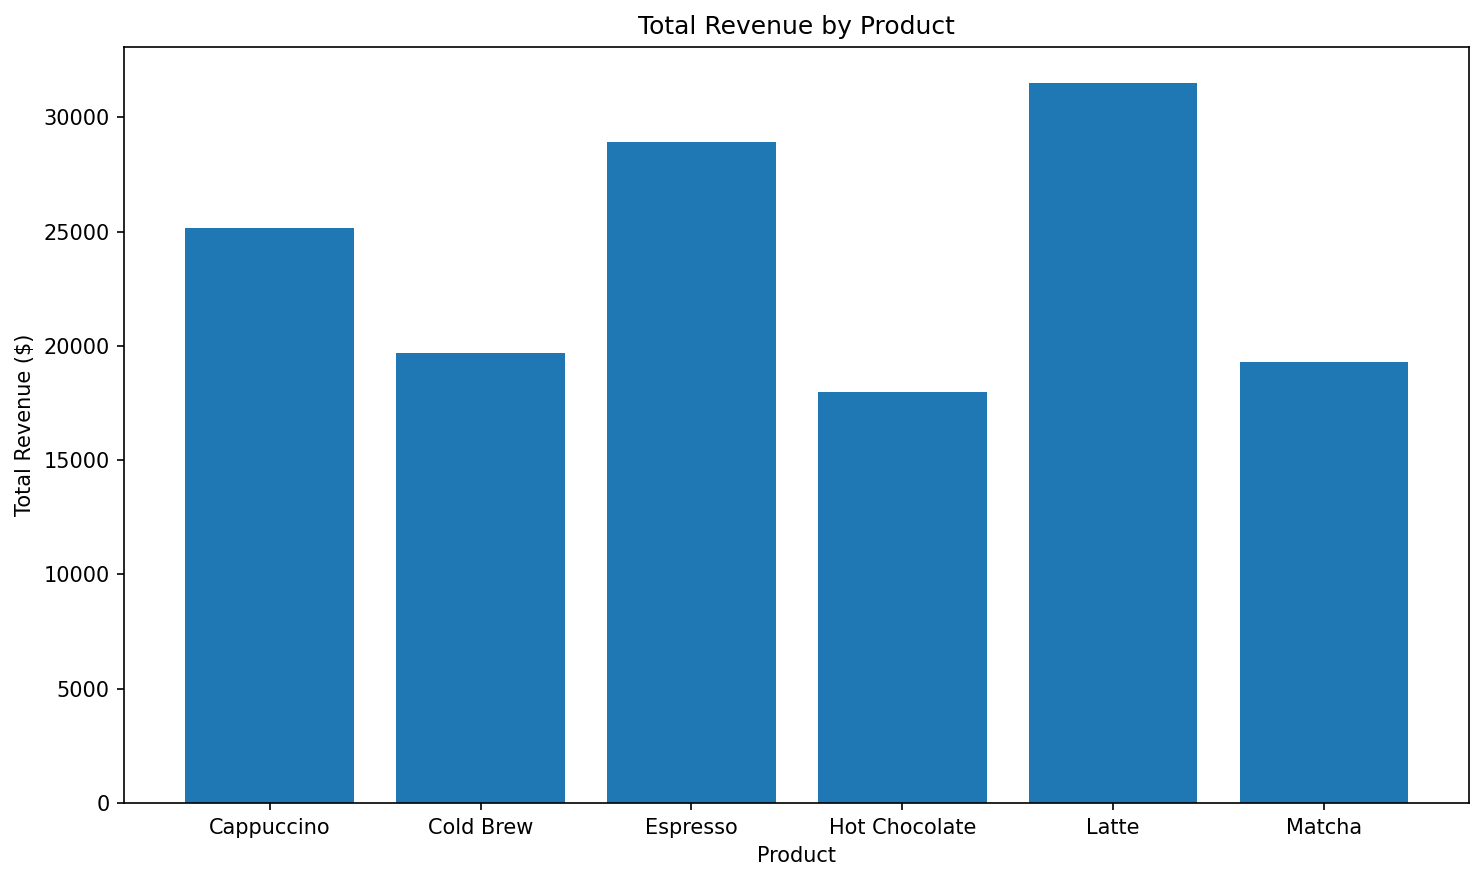

QUESTION: Show me monthly revenue for 2024

========== USER QUESTION ==========
Show me monthly revenue for 2024

🧠 GENERATED SQL:
SELECT 
    strftime('%Y-%m', date) AS month,
    SUM(revenue) AS total_revenue
FROM sales
WHERE CAST(strftime('%Y', date) AS INTEGER) = 2024
GROUP BY month;

🔍 VALIDATION RESULT:
VALID: True
ISSUES: None
FIXED QUERY: SELECT 
    strftime('%Y-%m', date) AS month,
    SUM(revenue) AS total_revenue
FROM sales
WHERE CAST(strftime('%Y', date) AS INTEGER) = 2024
GROUP BY month

📊 QUERY EXECUTED SUCCESSFULLY
DF COLUMNS: ['month', 'total_revenue']
     month  total_revenue
0  2024-01        13607.0
1  2024-02        12797.5
2  2024-03        11487.3
3  2024-04        11094.0
4  2024-05        11464.3
SQL: SELECT 
    strftime('%Y-%m', date) AS month,
    SUM(revenue) AS total_revenue
FROM sales
WHERE CAST(strftime('%Y', date) AS INTEGER) = 2024
GROUP BY month
INSIGHT: Based on the provided data, our analysis shows that the monthly revenue for 2024 is as follows: J

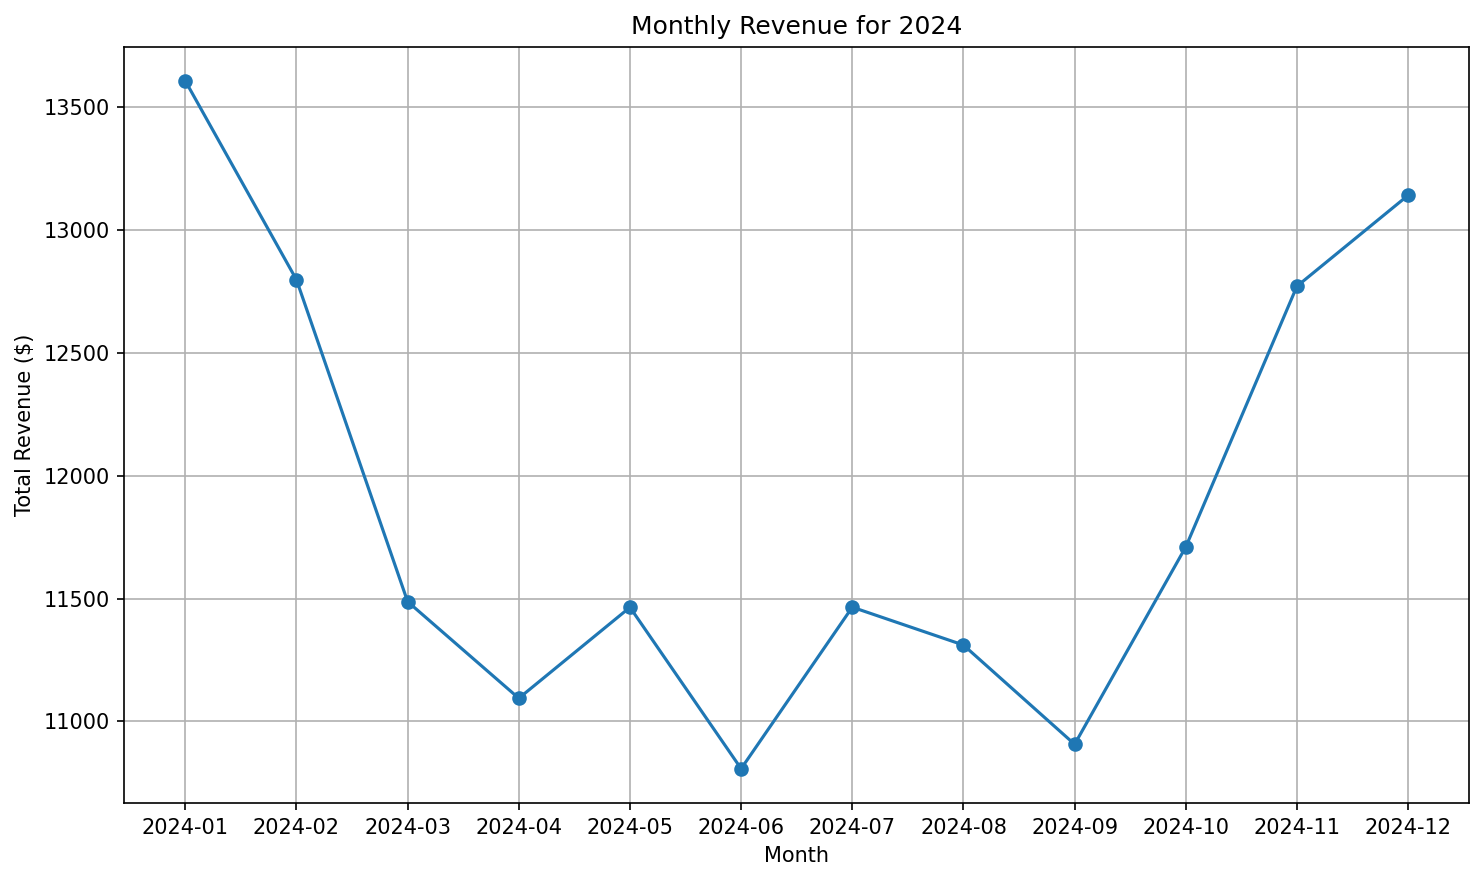

QUESTION: Which product had the highest sales in Q4?

========== USER QUESTION ==========
Which product had the highest sales in Q4?

🧠 GENERATED SQL:
WITH q4 AS (
    SELECT 
        ((CAST(strftime('%m', date) AS INTEGER) - 1) / 3) + 1 AS quarter,
        product,
        SUM(qty) AS total_qty
    FROM sales
    GROUP BY quarter, product
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY quarter
            ORDER BY total_qty DESC
        ) AS rn
    FROM q4
)
SELECT *
FROM ranked
WHERE rn = 1;

🔍 VALIDATION RESULT:
VALID: False
ISSUES: Missing GROUP BY when aggregating non-aggregated columns (quarter) and using ROW_NUMBER()
FIXED QUERY: WITH q4 AS (
    SELECT 
        ((CAST(strftime('%m', date) AS INTEGER) - 1) / 3) + 1 AS quarter,
        product,
        SUM(qty) AS total_qty
    FROM sales
    GROUP BY quarter, product, CAST(strftime('%m', date) AS INTEGER)
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY quarter
 

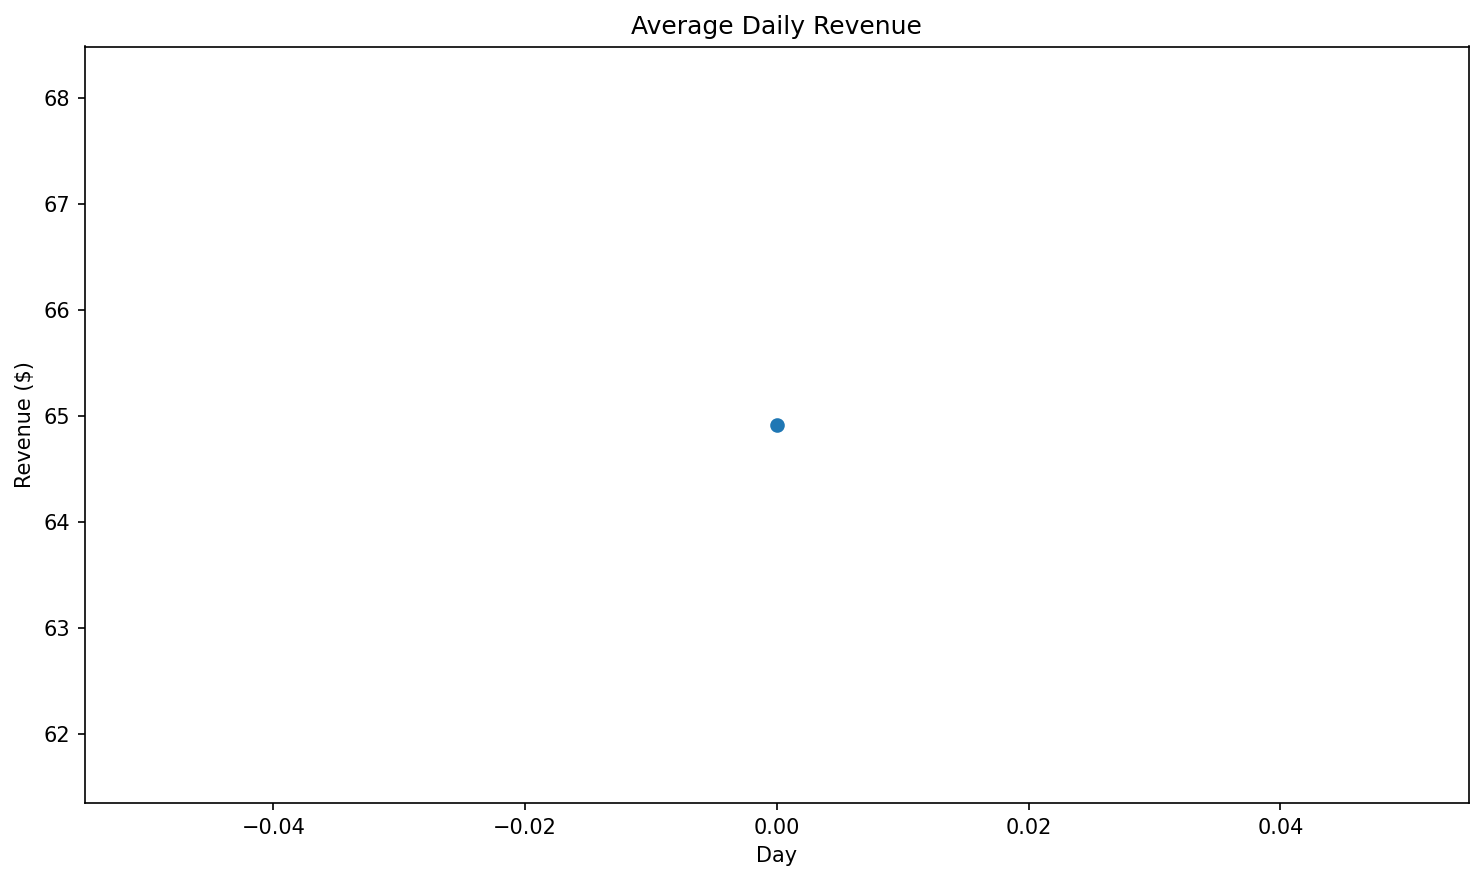

QUESTION: Compare hot vs cold drink sales by quantity

========== USER QUESTION ==========
Compare hot vs cold drink sales by quantity

🧠 GENERATED SQL:
WITH data AS (
    SELECT 
        CASE 
            WHEN product LIKE '%hot%' THEN 'hot'
            ELSE 'cold'
        END AS type,
        SUM(qty) AS total_qty
    FROM sales
    GROUP BY type
)
SELECT * FROM data
ORDER BY total_qty DESC;

🔍 VALIDATION RESULT:
VALID: True
ISSUES: Missing GROUP BY when aggregation and non-aggregated columns are mixed, SQLite supports strftime()
FIXED QUERY: WITH data AS (
    SELECT 
        CASE 
            WHEN product LIKE '%hot%' THEN 'hot'
            ELSE 'cold'
        END AS type,
        SUM(qty) AS total_qty
    FROM sales
    GROUP BY type, product
)
SELECT * FROM data
ORDER BY total_qty DESC;

📊 QUERY EXECUTED SUCCESSFULLY
DF COLUMNS: ['type', 'total_qty']
   type  total_qty
0  cold       8259
1  cold       6567
2  cold       5593
3  cold       4686
4   hot       4496
SQL: WITH data AS

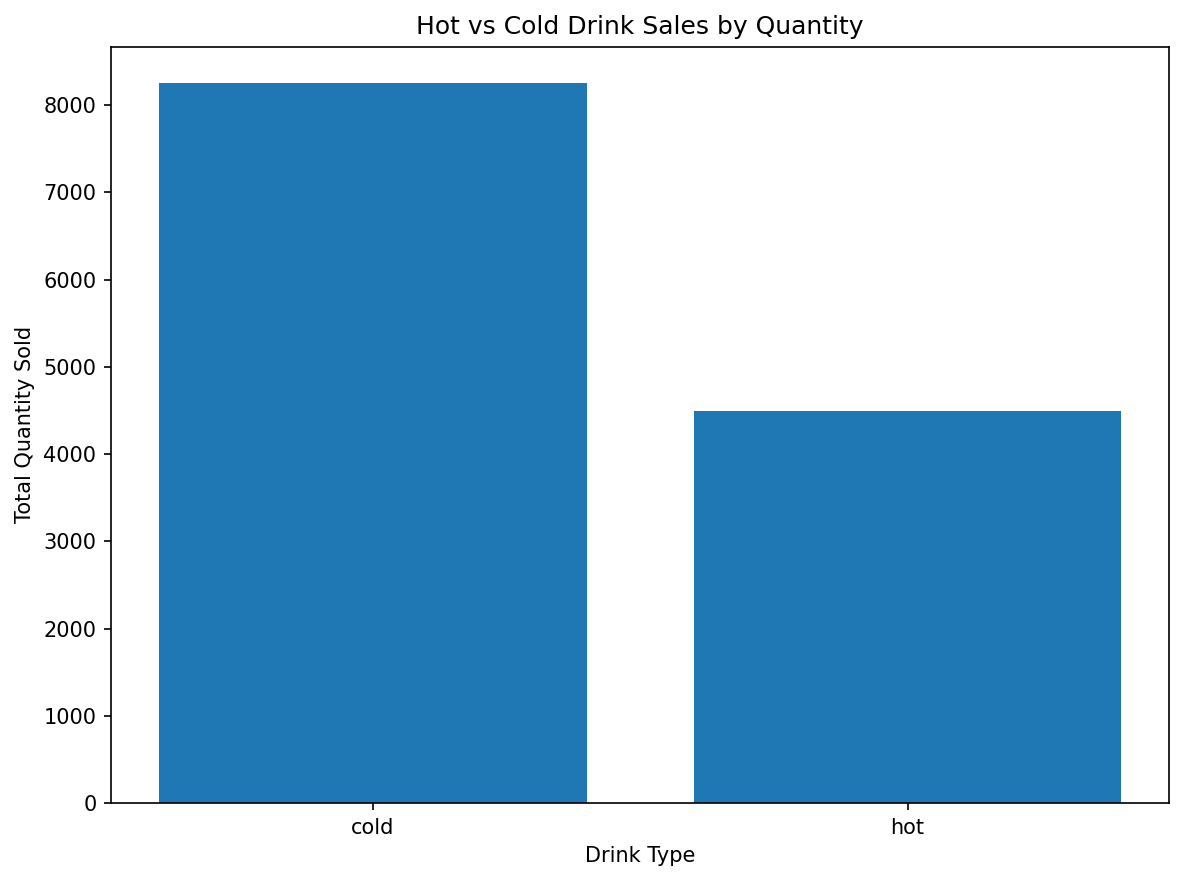

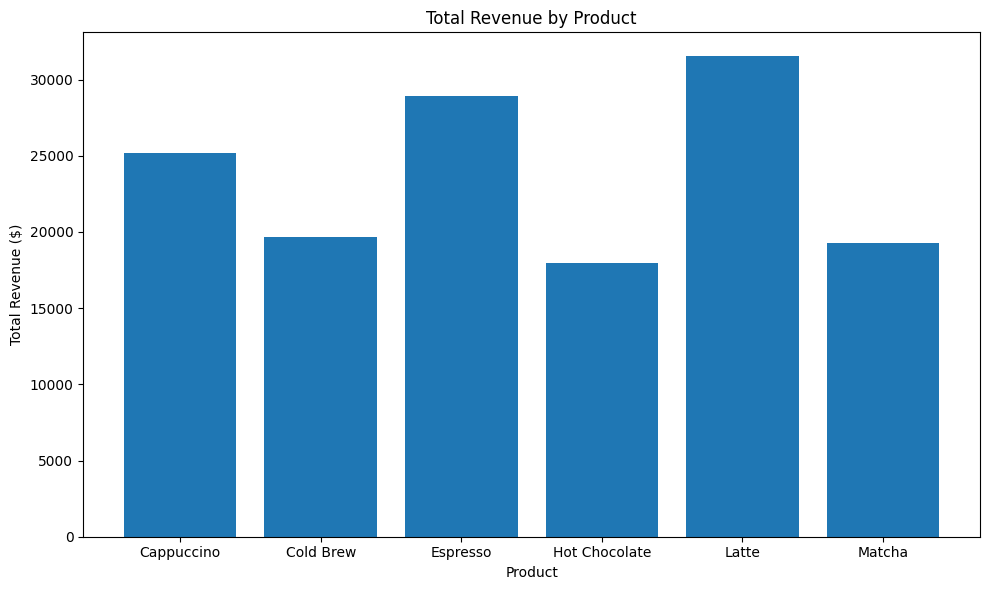

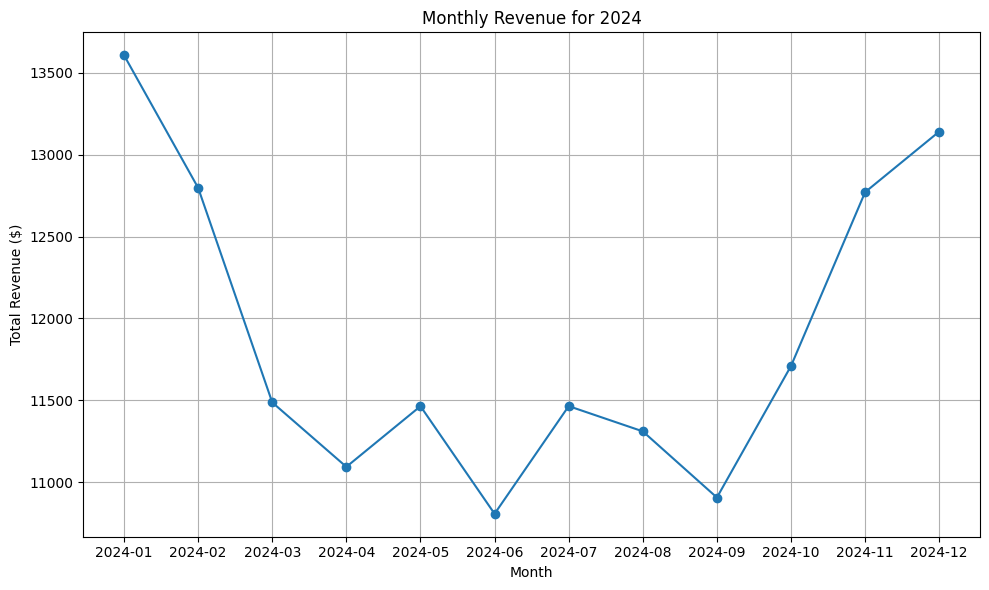

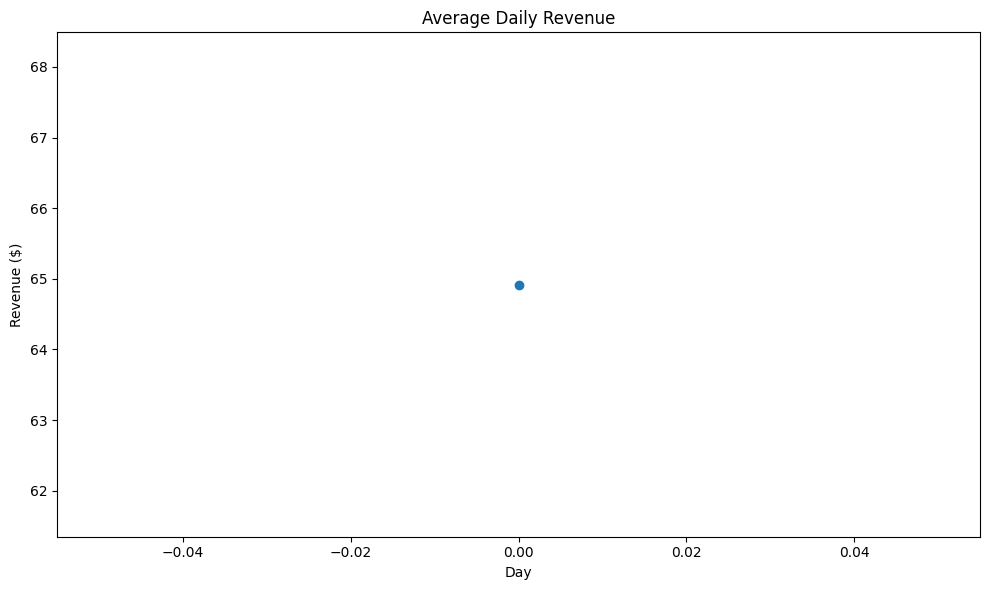

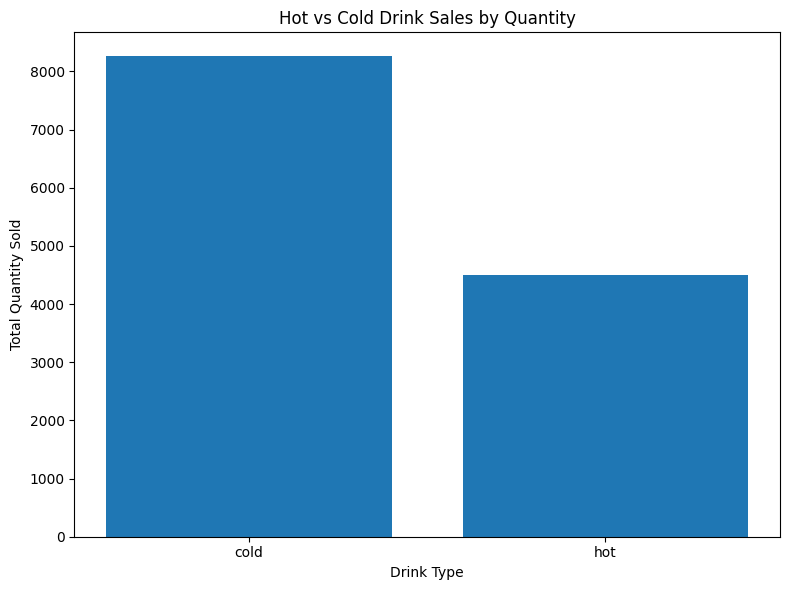

In [19]:
# ============================================================
# OPTIONAL — DISPLAY CHART HELPER
# ============================================================

def show_chart(chart_path: str = CHART_PATH) -> None:
    from IPython.display import Image, display
    if os.path.exists(chart_path):
        display(Image(filename=chart_path))
    else:
        print("Chart file not found.")


# ============================================================
# STEP 8 — TEST WITH 5 QUESTIONS
# ============================================================

test_questions = [   
     "What is the total revenue for each product?",
     "Show me monthly revenue for 2024",
     "Which product had the highest sales in Q4?",
     "What is the average daily revenue?",
     "Compare hot vs cold drink sales by quantity",
]
for q in test_questions:
    print("=" * 80)
    print("QUESTION:", q)
    result = analyse(q)
    print("SQL:", result.get("sql"))
    print("INSIGHT:", result.get("insight", result.get("error")))
    if result.get("chart"):
        show_chart(result["chart"])

In [14]:
import os
print(os.path.exists("coffee_analysis.png"))

True
